# Notebook 2: Sentiment Analysis Pipeline
### Day 3: Text Preprocessing

Dataset: NLTK's movie_reviews corpus — 2000 movie reviews labeled positive/negative. We'll tokenize, remove stopwords, and convert text into TF-IDF features.

In [1]:
import nltk
nltk.download("movie_reviews")
nltk.download("punkt")
nltk.download("stopwords")

from nltk.corpus import movie_reviews
import random

docs = [(movie_reviews.raw(fileid), category)
        for category in movie_reviews.categories()
        for fileid in movie_reviews.fileids(category)]

random.seed(42)
random.shuffle(docs)

texts = [d[0] for d in docs]
labels = [1 if d[1] == "pos" else 0 for d in docs]

print("Total reviews:", len(texts))
print("Positive:", labels.count(1), " Negative:", labels.count(0))
print("\nSample review:\n", texts[0][:300])

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total reviews: 2000
Positive: 1000  Negative: 1000

Sample review:
 mr . bean , a bumbling security guard from england is sent to la to help with the grandiose homecoming of a masterpiece american painting . 
the first two words should have said enough to let you know what occurs during bean's trip to la , but if they didn't look out because you are in for a rather 


In [2]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

sample = texts[0]
tokens = word_tokenize(sample.lower())
filtered = [t for t in tokens if t.isalpha() and t not in stop_words]

print("Original token count:", len(tokens))
print("After removing stopwords/punctuation:", len(filtered))
print("Sample filtered tokens:", filtered[:20])

Original token count: 631
After removing stopwords/punctuation: 270
Sample filtered tokens: ['mr', 'bean', 'bumbling', 'security', 'guard', 'england', 'sent', 'la', 'help', 'grandiose', 'homecoming', 'masterpiece', 'american', 'painting', 'first', 'two', 'words', 'said', 'enough', 'let']


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X_tfidf = tfidf.fit_transform(texts)

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Sample feature names:", tfidf.get_feature_names_out()[:20])

TF-IDF matrix shape: (2000, 5000)
Sample feature names: ['000' '10' '100' '11' '12' '13' '13th' '14' '15' '16' '17' '18' '1900'
 '1960' '1960s' '1970s' '1980' '1980s' '1981' '1984']


### Day 4: Sentiment Classifier — Logistic Regression + Naive Bayes

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, labels, test_size=0.2, random_state=42, stratify=labels
)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_preds))
print(classification_report(y_test, logreg_preds))

Logistic Regression Accuracy: 0.8125
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       200
           1       0.80      0.83      0.82       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



In [7]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds))

Naive Bayes Accuracy: 0.7825
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       200
           1       0.82      0.73      0.77       200

    accuracy                           0.78       400
   macro avg       0.79      0.78      0.78       400
weighted avg       0.79      0.78      0.78       400



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

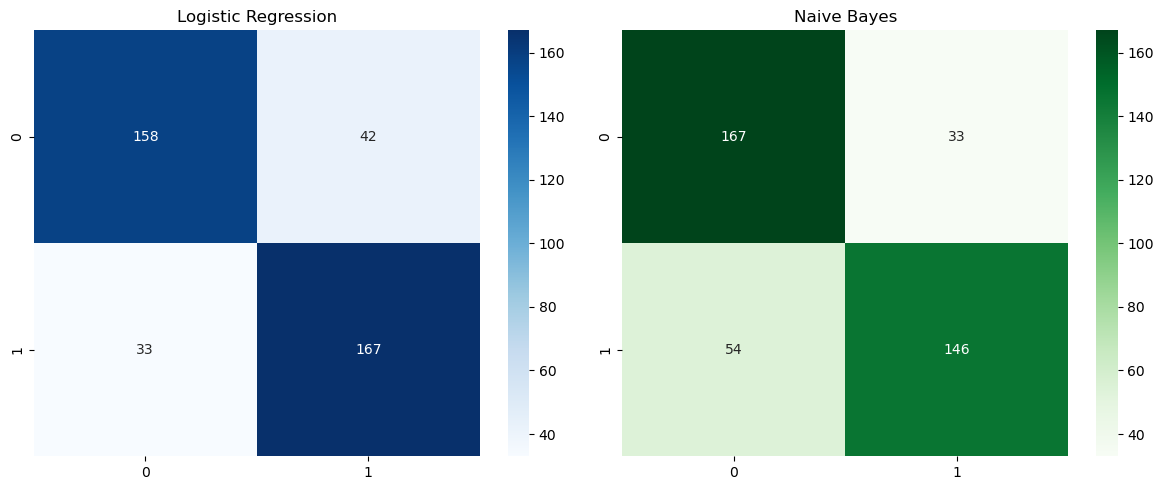

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, logreg_preds), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Naive Bayes")

plt.tight_layout()
plt.show()